# Main EDA

***With the structural issues from round 1 resolved, this notebook shifts focus from fixing the data to understanding it. The dataset loaded here is `games_clean_r1.csv`: null columns removed, column misalignment corrected, non game entries filtered out, and all dtypes in order.***

***The goal is to move from a structurally sound dataset to one we genuinely understand before modelling. That means examining how review counts, prices, and release years are distributed; how genres and tags break down across the catalogue; and how time-on-market interacts with the engagement metrics we care about. It also means confronting a key property of this dataset: review counts and playtime figures are cumulative totals up to the snapshot date(Jan, 2025), not normalised per year figures. A 2010 game and a 2022 game are not directly comparable on raw counts alone, and this notebook will establish how we handle that.***

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

script_path = Path.cwd()
data_path = script_path.parent/"data"/"processed"/"games_clean_r1.csv"

df = pd.read_csv(data_path)
df.shape

(113065, 35)

In [2]:
pd.set_option('display.max_columns', None)
df.head(5)

,AppID,Name,Release date,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Header image,Support email,Windows,Mac,Linux,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Min owners,Max owners,Avg owners
0,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],https://shared.akamai.steamstatic.com/store_it...,support@mangagamer.com,True,False,False,0,0,252,3,0,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,0,20000,10000.0
1,1034400,Mystery Solitaire The Black Raven,2019-05-06,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],https://shared.akamai.steamstatic.com/store_it...,support@8floor.net,True,True,False,0,0,21,3,0,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,0,20000,10000.0
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],https://shared.akamai.steamstatic.com/store_it...,yujingamesc@gmail.com,True,False,False,0,0,0,0,19,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,0,20000,10000.0
3,3631080,Maze Quest VR,2025-04-24,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],https://shared.akamai.steamstatic.com/store_it...,support@realityexpanded.com,True,False,False,0,0,0,0,0,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,0,20000,10000.0
4,1654170,Agony VR,2023-04-05,0,0,13.99,0,0,A JOURNEY THROUGH HELL! Explore the most terri...,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Turkish']",https://shared.akamai.steamstatic.com/store_it...,office@ignibit.com,True,False,False,0,0,0,0,0,0,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...,0,20000,10000.0


In [3]:
df.describe()

,AppID,Peak CCU,Required age,Price,Discount,DLC count,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Min owners,Max owners,Avg owners
count,1.130650e+05,1.130650e+05,113065.000000,113065.000000,113065.000000,113065.000000,113065.000000,113065.000000,1.130650e+05,1.130650e+05,113065.000000,1.130650e+05,1.130650e+05,113065.000000,1.130650e+05,113065.000000,1.130650e+05,1.130650e+05,1.130650e+05
mean,1.923613e+06,5.728773e+01,0.181497,5.030217,19.774528,0.565206,2.781497,0.026622,1.121464e+03,1.828297e+02,19.514713,1.032624e+03,2.137749e+02,14.471508,1.778443e+02,15.474019,5.374537e+04,1.303623e+05,9.205382e+04
std,1.076286e+06,3.871566e+03,1.720087,12.690801,29.499549,14.538825,14.204369,1.452574,2.913343e+04,5.596425e+03,147.244506,2.262991e+04,1.165476e+04,277.585380,1.163651e+04,302.653801,8.678413e+05,1.811233e+06,1.338399e+06
min,1.000000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.014050e+06,0.000000e+00,0.000000,0.890000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,2.000000e+04,1.000000e+04
50%,1.823990e+06,0.000000e+00,0.000000,2.690000,0.000000,0.000000,0.000000,0.000000,7.000000e+00,1.000000e+00,5.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,2.000000e+04,1.000000e+04
75%,2.786380e+06,0.000000e+00,0.000000,5.990000,50.000000,0.000000,0.000000,0.000000,4.400000e+01,1.200000e+01,20.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,2.000000e+04,1.000000e+04
max,4.264350e+06,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,1.000000e+08,2.000000e+08,1.500000e+08


## Review Distribution

***As observed during initial EDA and confirmed by `df.describe()` output, the dataset exhibits an extreme left skew. To better visualize this, we will plot histograms for key numeric columns. Where the skew is severe, we will apply log transformations to normalize the distributions and make the data more suitable for downstream modeling.***

In [4]:
df['Review_Count'] = df['Positive'] + df['Negative']
df['Review_Ratio'] = df['Positive'] / df['Review_Count']
df[['Review_Count', 'Review_Ratio']].describe()

,Review_Count,Review_Ratio
count,1.130650e+05,81837.000000
mean,1.304294e+03,0.758839
std,3.387854e+04,0.238524
min,0.000000e+00,0.000000
25%,0.000000e+00,0.650108
50%,9.000000e+00,0.819277
75%,5.800000e+01,0.944444
max,8.815087e+06,1.000000


***Due to the extreme skewness in review counts, the raw positive ratio becomes misleading as a standalone metric, a game with 2 positive out of 3 reviews carries the same ratio as one with 400 out of 600, despite the latter being statistically far more reliable. For this reason, review count alone will be used
throughout the raw data analysis as a proxy for engagement until the success metric is introduced, at which point a more statistical measure will replace it.***

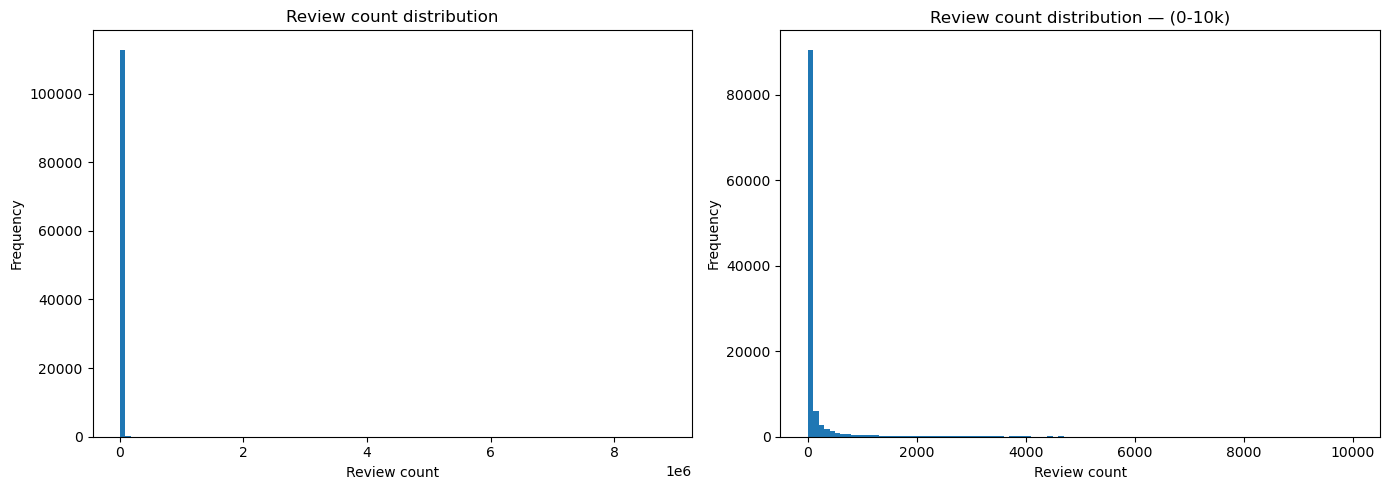

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(14,5))

plt.subplot(1,2,1)
plt.hist(df['Review_Count'], bins=100)
plt.title('Review count distribution')
plt.xlabel('Review count')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.hist(df[df['Review_Count'] <= 10000]['Review_Count'], bins=100)
plt.title('Review count distribution — (0-10k)')
plt.xlabel('Review count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

***The raw review count distribution reveals two overlapping problems: zero-inflation, with the majority of games having no reviews whatsoever, 
and extreme right skew driven by a small number of titles with hundreds of thousands of reviews. These two properties together make raw review count unusable as a target variable without transformation. The next cell applies log1p to compress the scale and make the distribution workable for modelling.***

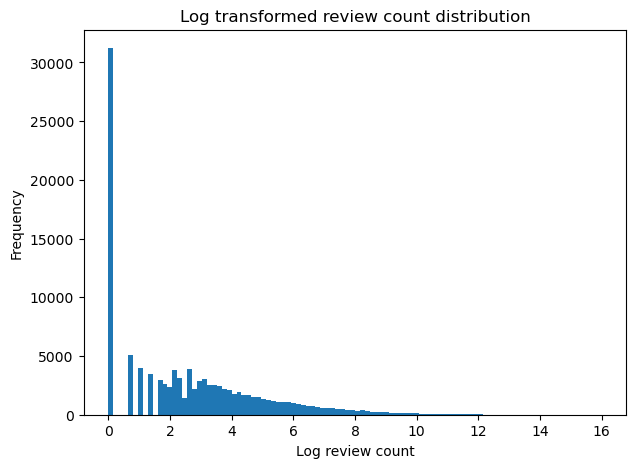

In [6]:
log_review_count = np.log1p(df['Review_Count'])

plt.figure(figsize=(7, 5))
plt.hist(log_review_count, bins=100)
plt.title('Log transformed review count distribution')
plt.xlabel('Log review count')
plt.ylabel('Frequency')
plt.show()

***Applying log1p compresses the extreme right tail and makes the  distribution legible, the bulk of games now spread across a readable scale rather than collapsing into a single bar. However, the spike at zero persists, confirming that zero-inflation is a structural property of this dataset rather than a scaling artefact: the majority of games  on Steam have never received a single review. Games with zero reviews cannot have a meaningful target variable and will be dropped in notebook 04 before modelling.***

---

## Price Distribution

***Price is one of the few signals in this dataset that a developer controls directly at launch, making it a natural candidate for analysis and a core feature for modelling. Before examining any relationship between price and success, it is worth understanding the shape of the price landscape itself: how many games are free versus paid, where paid games cluster, and how extreme the outliers are.***

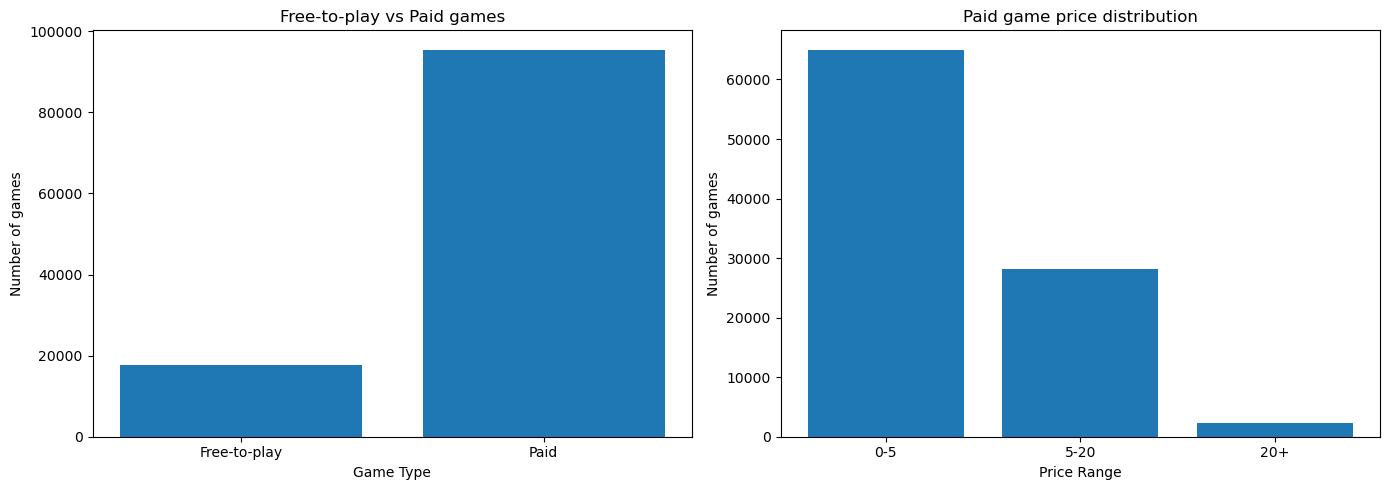

In [7]:
ftp_count = df[df['Price'] == 0]
paid_count = df[df['Price'] > 0]

fig, axes = plt.subplots(1,2,figsize=(14,5))

plt.subplot(1,2,1)
plt.bar(['Free-to-play', 'Paid'], [len(ftp_count), len(paid_count)])
plt.title('Free-to-play vs Paid games')
plt.ylabel('Number of games')
plt.xlabel('Game Type')

plt.subplot(1,2,2)
plt.bar(['0-5','5-20','20+'], [len(paid_count[paid_count['Price'] <= 5]), len(paid_count[(paid_count['Price'] > 5) & (paid_count['Price'] <= 20)]), len(paid_count[paid_count['Price'] > 20])])
plt.title('Paid game price distribution')
plt.ylabel('Number of games')
plt.xlabel('Price Range')

plt.tight_layout()
plt.show()

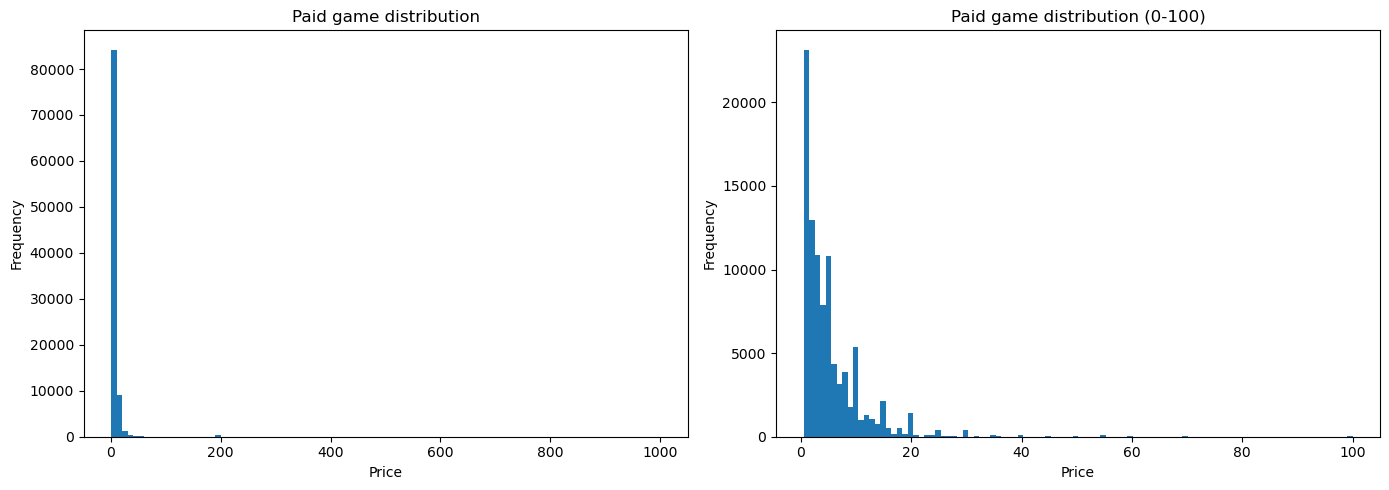

In [8]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

plt.subplot(1,2,1)
plt.hist(paid_count['Price'], bins=100)
plt.title('Paid game distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.hist(paid_count[paid_count['Price'] <= 100]['Price'], bins=100)
plt.title('Paid game distribution (0-100)')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

***The price distribution tells a clear story. The majority of games on Steam are `free-to-play`, and among paid titles the market is heavily concentrated in the `budget tier`, most games are priced below 5 with a rapid drop off beyond 20. The zoomed histogram confirms that the `0–20 range` captures the vast bulk of paid releases, while the long tail extending toward 100 and beyond represents a small number of premium or niche titles. Like review counts, the paid price distribution is right-skewed and will require a `log1p` transform before modelling. The free-to-play flag will be retained as a separate binary feature, since the dynamics of free games — and what drives their success — are likely to differ meaningfully from paid titles.***

---

## Time Released

***Because the dataset is a `snapshot` taken in January 2025, the data for each entry is `cumulative`. Consequently, older games have a natural advantage, having had more time to accumulate statistics and gain exposure. One potential solution is to normalize the data by dividing each entry's statistics by its time since release, however, this measures annualized growth rather than absolute success. To account for this bias, we will introduce a new variable tracking the time passed since release, which will be utilized in  future analysis.***

In [9]:
df['Release date'] = pd.to_datetime(df['Release date'])

snapshot = pd.Timestamp('2026-01-05')
df['game_age_days'] = (snapshot - df['Release date']).dt.days
print(df['game_age_days'].describe())

count    113065.000000
mean       1496.695069
std        1212.671193
min           0.000000
25%         490.000000
50%        1214.000000
75%        2292.000000
max       10416.000000
Name: game_age_days, dtype: float64


***`Release date` needed to be converted back to `datetime` once more. Since CSV files store all data as plain text, saving the cleaned dataset to `games_clean_r1.csv` in the previous notebook caused the column to lose its `datetime` type, when read back into this notebook, pandas parses it again as an `object`. This is expected CSV behaviour rather than a new issue, and will be addressed again during the final cleaning step. For now, the focus is on visualising and analysing this column in its current form.***

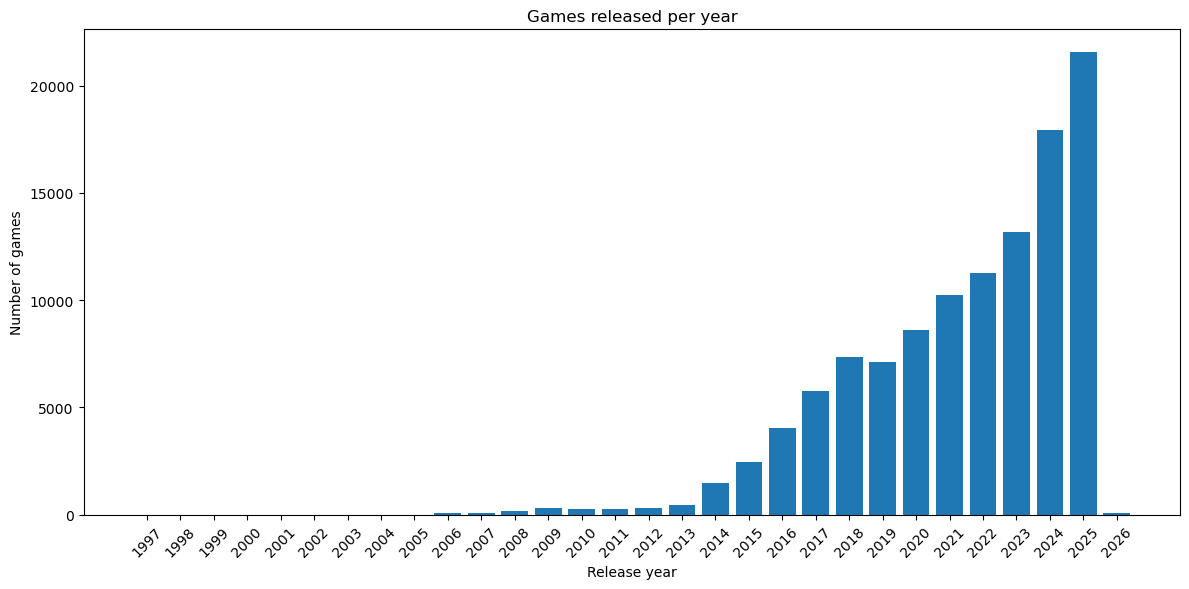

In [10]:
release_year_counts = df['Release date'].dt.year.value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.bar(release_year_counts.index.astype(str), release_year_counts.values)
plt.title('Games released per year')
plt.xlabel('Release year')
plt.ylabel('Number of games')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

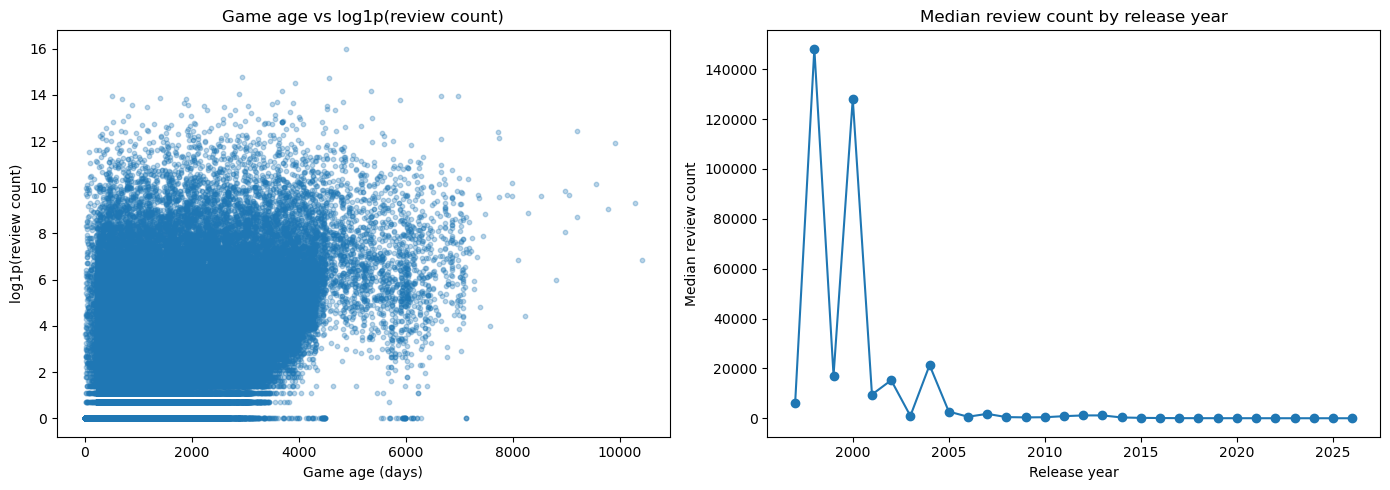

In [11]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

plt.subplot(1,2,1)
plt.scatter(df['game_age_days'], np.log1p(df['Review_Count']), alpha=0.3, s=10)
plt.title('Game age vs log1p(review count)')
plt.xlabel('Game age (days)')
plt.ylabel('log1p(review count)')


median_reviews_by_year = (
    df.groupby(df['Release date'].dt.year)['Review_Count']
    .median()
    .reset_index()
)
median_reviews_by_year.columns = ['year', 'median_review_count']

plt.subplot(1,2,2)
plt.plot(median_reviews_by_year['year'], median_reviews_by_year['median_review_count'], marker='o')
plt.title('Median review count by release year')
plt.xlabel('Release year')
plt.ylabel('Median review count')
plt.tight_layout()
plt.show()

***This comparison makes the platform's macro trends explicit. As annual Steam releases climbed from a few thousand in `2010` to over 20,000 by `2025`, the median review count collapsed toward zero. The two trends cross almost exactly where the platform's catalog growth accelerated around `2014–2015`. On the scatter plot, age does appear to give games a better chance of escaping the zero review floor, as the density of low-scoring points visibly thins out past the `4,000-day` mark. However, pure age does not guarantee a top performer; the single highest point on the plot sits at a relatively young age rather than the far-right extreme. The most accurate reading is that age provides a slow, compounding advantage, whereas a modern viral hit can bypass that timeline entirely.***

***However, the line chart on the right reveals a severe small-sample artifact. Because early Steam cohorts contained only a handful of games, a single monumental legacy title (such as `Half-Life` or `Counter-Strike`) is enough to drag the entire annual ***median*** upward, producing the massive artificial spikes seen in `1998` and `2000`. To observe the genuine modern trend of review accumulation, this visual must be restricted to years where the denominator is large enough to render the median meaningful. Based on the catalog's historical distribution, zooming in on `2010 onward`—when annual releases finally reach into the hundreds—will serve as our ideal analytical cutoff.***

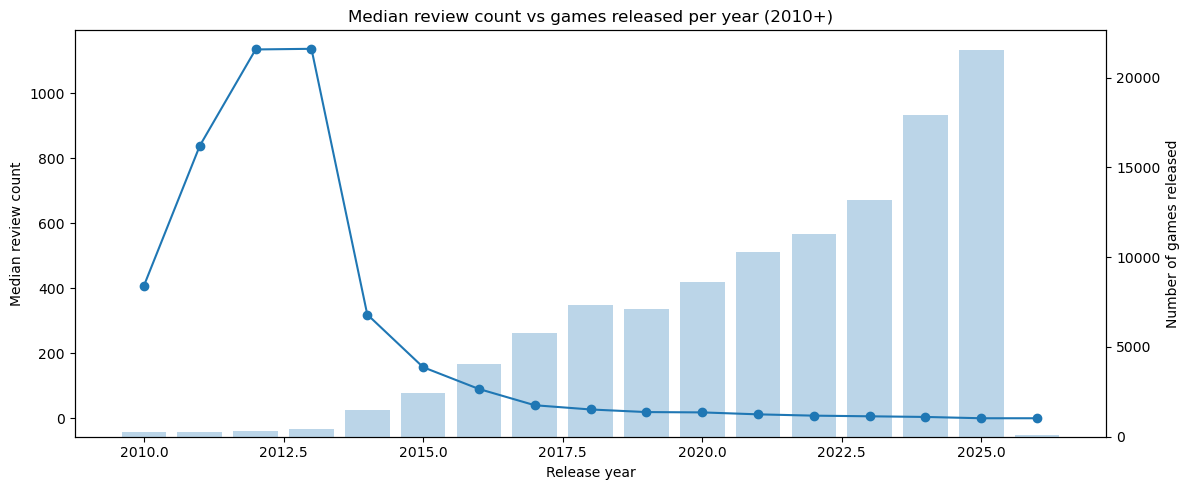

In [12]:
median_reviews_by_year_filtered = median_reviews_by_year[median_reviews_by_year['year'] >= 2010]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(median_reviews_by_year_filtered['year'], median_reviews_by_year_filtered['median_review_count'], 
         marker='o', label='Median review count')
ax1.set_xlabel('Release year')
ax1.set_ylabel('Median review count')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
release_year_counts_filtered = release_year_counts[release_year_counts.index >= 2010]
ax2.bar(release_year_counts_filtered.index, release_year_counts_filtered.values, 
        alpha=0.3, label='Games released')
ax2.set_ylabel('Number of games released')
ax2.tick_params(axis='y')

plt.title('Median review count vs games released per year (2010+)')
fig.tight_layout()
plt.show()

***Even after restricting to `2010` onward, the relationship holds cleanly: median review count peaks around `2012–2013` at over `1,100`, then falls sharply as annual release volume climbs past a few thousand games per year, settling near zero by `2017` and staying there through `2025`. The crossover point lines up almost exactly with where the bars start climbing steeply, reinforcing that this is a dilution effect rather than a quality decline, far more games are competing for attention each year, and most simply haven't had the runway to accumulate reviews yet.***

***With the temporal dimension understood, the next step is to look at how success is distributed across genres and tags, and whether any apparent differences between categories are genuine or simply another reflection of how long each genre has existed on the platform.***

## Genre and Tag Breakdown

### Genre

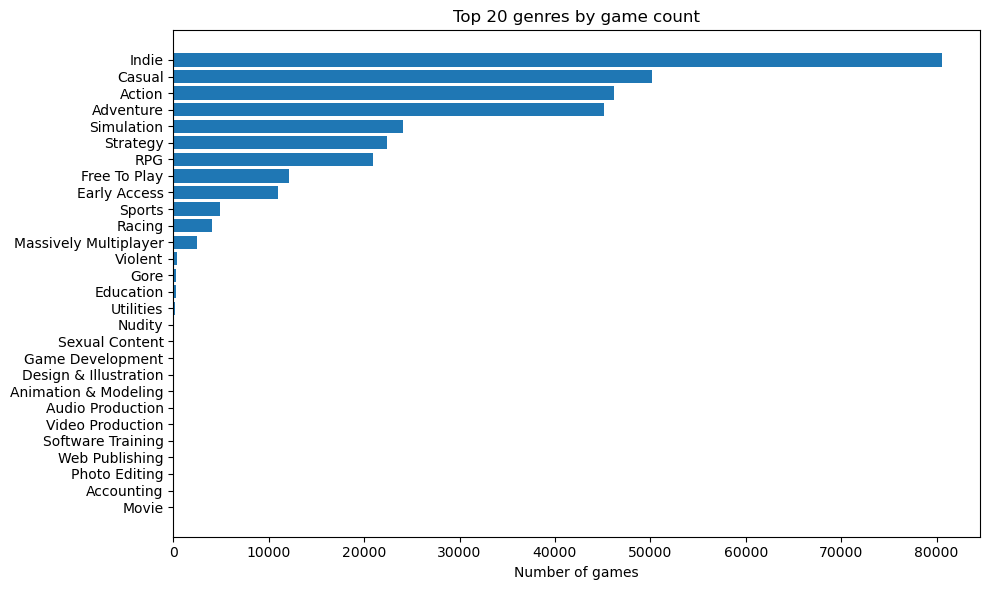

In [13]:
genre_series = df['Genres'].dropna().str.split(',').explode().str.strip()
genre_counts = genre_series.value_counts()

plt.figure(figsize=(10, 6))
plt.barh(genre_counts.index[::-1], genre_counts.values[::-1])
plt.title('Top 20 genres by game count')
plt.xlabel('Number of games')
plt.tight_layout()
plt.show()

***With the top 20 genres identified by frequency, the next question is whether genres with higher `average review counts` simply reflect genres that have existed on the platform longer. The chart below plots `average review count` against `average game age` for the same set of genres, using the same dual-axis approach from the time on market analysis, to check whether the two move together or independently.***

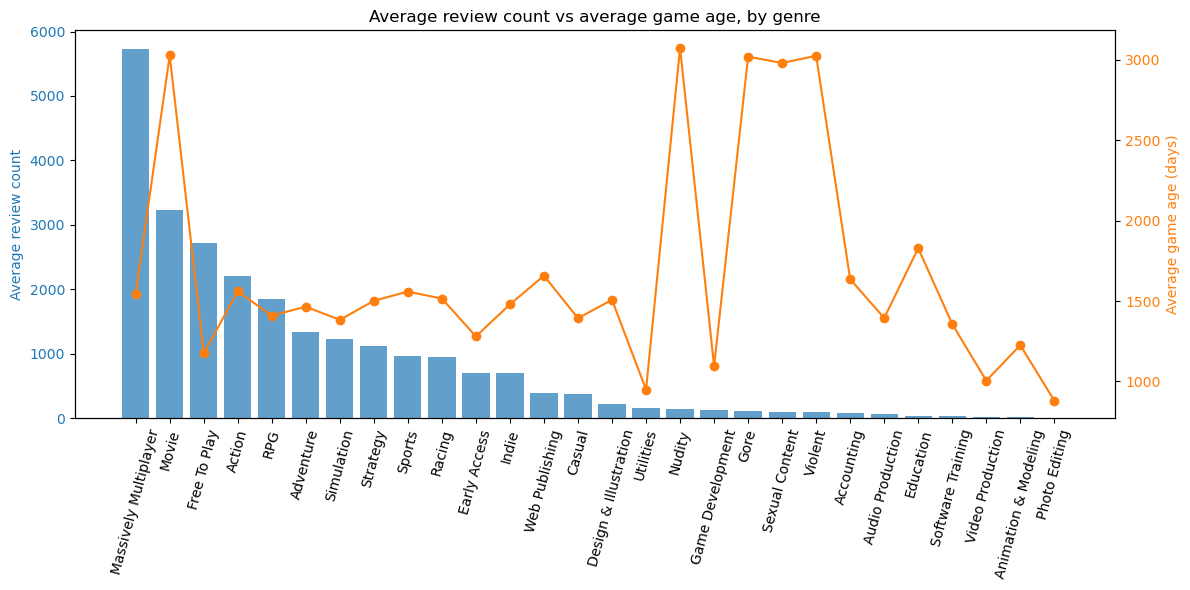

In [14]:
df_genre_exploded = (
    df[['Genres', 'Review_Count', 'game_age_days']]
    .dropna(subset=['Genres'])
    .assign(genre=df['Genres'].str.split(','))
    .explode('genre')
    .assign(genre=lambda x: x['genre'].str.strip())
)

top_genres = genre_counts.index.tolist()
df_genre_top = df_genre_exploded[df_genre_exploded['genre'].isin(top_genres)]

genre_stats = (
    df_genre_top.groupby('genre')
    .agg(avg_review_count=('Review_Count', 'mean'), avg_age_days=('game_age_days', 'mean'))
    .sort_values('avg_review_count', ascending=False)
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(genre_stats.index, genre_stats['avg_review_count'], color='tab:blue', alpha=0.7, label='Avg review count')
ax1.set_ylabel('Average review count', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=75)

ax2 = ax1.twinx()
ax2.plot(genre_stats.index, genre_stats['avg_age_days'], color='tab:orange', marker='o', label='Avg age (days)')
ax2.set_ylabel('Average game age (days)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Average review count vs average game age, by genre')
fig.tight_layout()
plt.show()

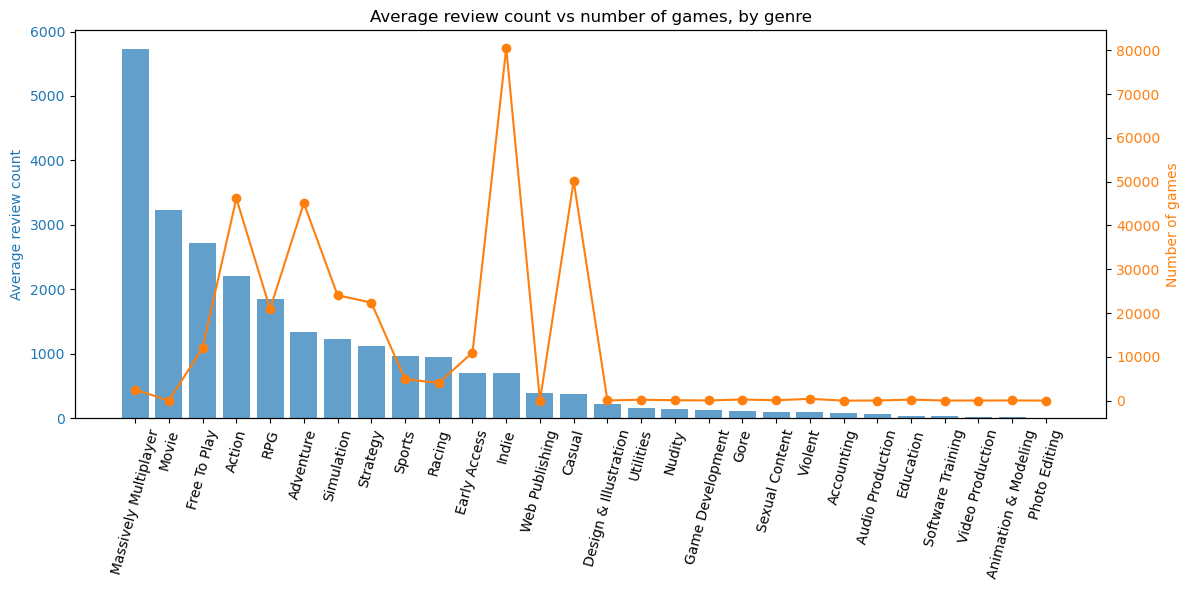

In [15]:
genre_game_counts = df_genre_exploded[df_genre_exploded['genre'].isin(top_genres)]['genre'].value_counts()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(genre_stats.index, genre_stats['avg_review_count'], color='tab:blue', alpha=0.7)
ax1.set_ylabel('Average review count', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=75)

ax2 = ax1.twinx()
ax2.plot(genre_stats.index, 
         genre_game_counts.reindex(genre_stats.index).values, 
         color='tab:orange', marker='o')
ax2.set_ylabel('Number of games', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Average review count vs number of games, by genre')
fig.tight_layout()
plt.show()

***Neither chart shows a consistent relationship between a genre's average review count and either its average age or the number of games competing within it. Genres like `Massively Multiplayer` and `Free To Play` top the review count ranking despite only moderate `average ages`, while several of the oldest genres on the platform sit near the bottom despite having existed the longest. The same independence holds against catalogue size, since some of the most crowded genres do not show correspondingly lower averages. This suggests genre carries genuine predictive signal rather than simply encoding how long a category has existed or how saturated it is.***

---

### Tags

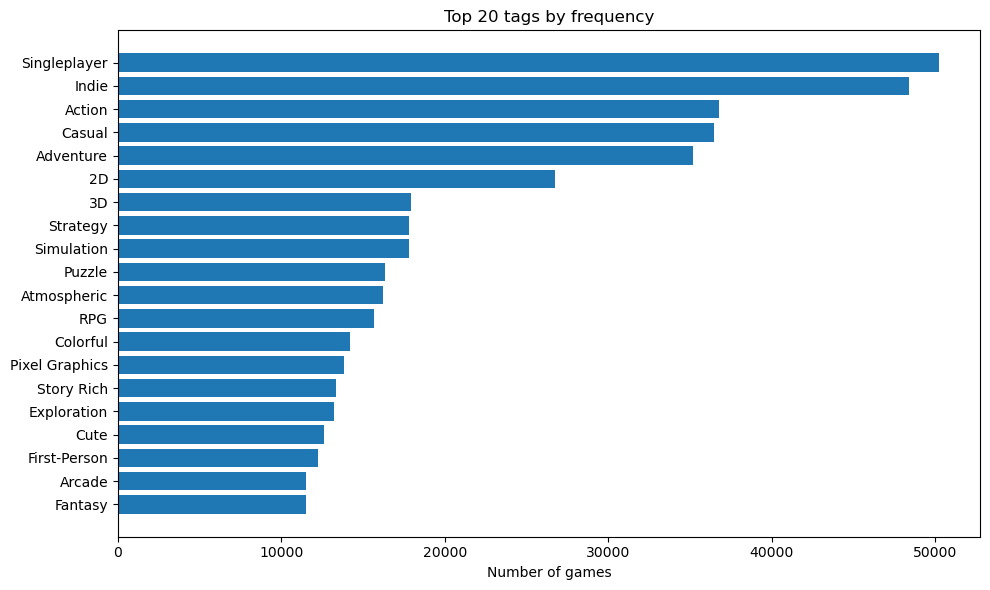

In [16]:
tag_series = df['Tags'].dropna().str.split(',').explode().str.strip()
tag_counts = tag_series.value_counts().head(20)

plt.figure(figsize=(10, 6))
plt.barh(tag_counts.index[::-1], tag_counts.values[::-1])
plt.title('Top 20 tags by frequency')
plt.xlabel('Number of games')
plt.tight_layout()
plt.show()

***Tags offer a more granular view than genre, since a single game can carry many descriptive tags rather than a small fixed set of categories. The same age adjusted lens applied to genres is repeated here, checking whether high performing tags simply reflect tags that have been in use longer on the platform.***

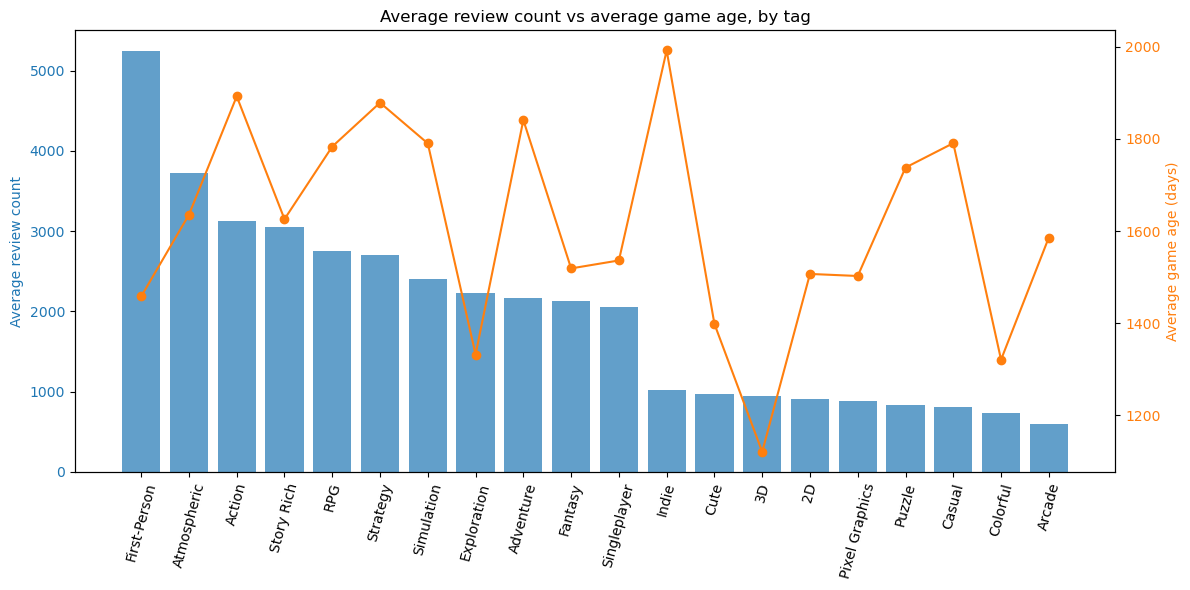

In [17]:
df_tag_exploded = (
    df[['Tags', 'Review_Count', 'game_age_days']]
    .dropna(subset=['Tags'])
    .assign(tag=df['Tags'].str.split(','))
    .explode('tag')
    .assign(tag=lambda x: x['tag'].str.strip())
)

top_tags = tag_counts.index.tolist()
df_tag_top = df_tag_exploded[df_tag_exploded['tag'].isin(top_tags)]

tag_stats = (
    df_tag_top.groupby('tag')
    .agg(avg_review_count=('Review_Count', 'mean'), avg_age_days=('game_age_days', 'mean'))
    .sort_values('avg_review_count', ascending=False)
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(tag_stats.index, tag_stats['avg_review_count'], color='tab:blue', alpha=0.7, label='Avg review count')
ax1.set_ylabel('Average review count', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=75)

ax2 = ax1.twinx()
ax2.plot(tag_stats.index, tag_stats['avg_age_days'], color='tab:orange', marker='o', label='Avg age (days)')
ax2.set_ylabel('Average game age (days)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Average review count vs average game age, by tag')
fig.tight_layout()
plt.show()

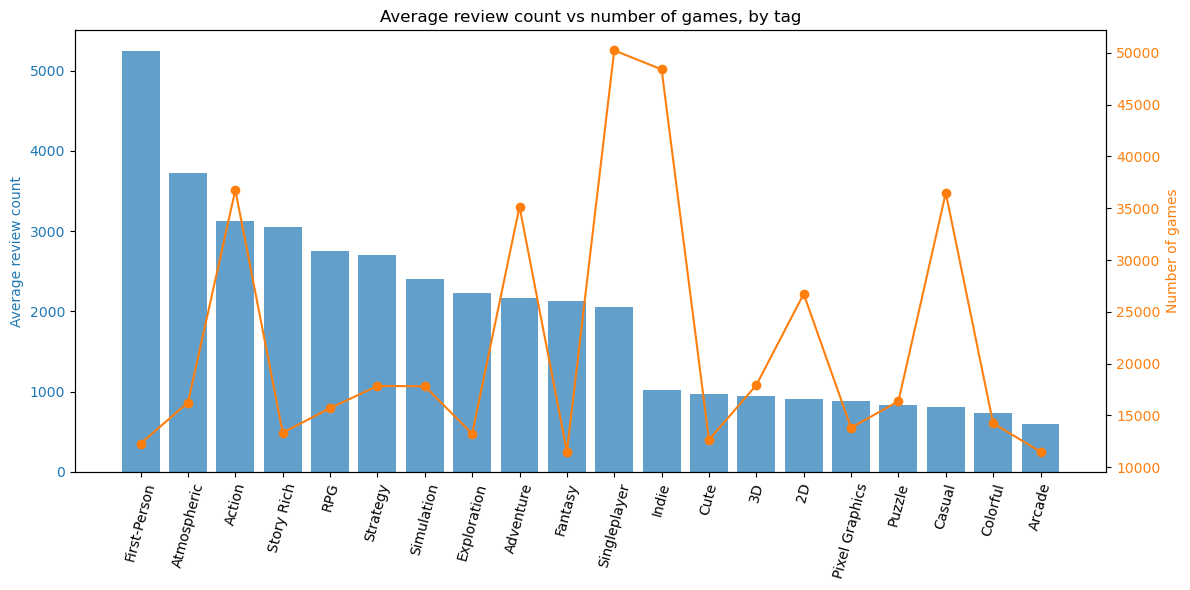

In [18]:
tag_game_counts = df_tag_exploded[df_tag_exploded['tag'].isin(top_tags)]['tag'].value_counts()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(tag_stats.index, tag_stats['avg_review_count'], color='tab:blue', alpha=0.7)
ax1.set_ylabel('Average review count', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=75)

ax2 = ax1.twinx()
ax2.plot(tag_stats.index, 
         tag_game_counts.reindex(tag_stats.index).values, 
         color='tab:orange', marker='o')
ax2.set_ylabel('Number of games', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Average review count vs number of games, by tag')
fig.tight_layout()
plt.show()

***The tag level results echo the genre level findings: `average review count` does not track cleanly with either `average age` or `tag frequency`, reinforcing that these category level differences are unlikely to be pure artefacts of time on market or catalogue saturation. One caveat applies to all four charts in this section: average review count treats positive and negative reviews equally, so a genre or tag with high volume but poor sentiment would appear identical to one with high volume and strong sentiment. This is addressed from section 4 onward, where the composite success score incorporating sentiment confidence replaces raw review count as the primary metric.***

---

## Success Parameter

***One `limitation` applies to the genre and tag breakdowns above: `average review count` treats positive and negative reviews equally, so a genre with high average volume but poor sentiment would appear the same as one with high volume and strong sentiment. This is addressed previously, where the composite success score incorporating both volume and `Wilson lower bound` sentiment confidence replaces raw review count as the primary metric.***

An alternative to the `Wilson lower bound` considered here was the `Bayesian average`, a weighted blend between a game's observed positive ratio and a global prior (dataset's overall average rating), which is the approach used by IMDb for movie rankings; both methods solve the same core problem of an unreliable raw ratio at low review counts, but the Bayesian approach requires choosing and justifying a prior, which is harder to defend given how skewed and zero inflated this dataset already is, since there is no stable, well-justified notion of an "average" game to anchor the prior to, whereas the Wilson lower bound only uses each game's own observed ratio and sample size, with no reference to the rest of the dataset, making it the more defensible choice here.

In [19]:
from statsmodels.stats.proportion import proportion_confint

def wilson_lower(pos, neg):
    n = pos + neg
    if n == 0:
        return 0
    lower, _ = proportion_confint(pos, n, alpha=0.05, method='wilson')
    return lower

df['wilson_lb'] = df.apply(lambda row: wilson_lower(row['Positive'], row['Negative']), axis=1)
df['success_score'] = np.log1p(df['Review_Count']) * df['wilson_lb']

df[['Positive', 'Negative', 'Review_Count', 'wilson_lb', 'success_score']].describe()

,Positive,Negative,Review_Count,wilson_lb,success_score
count,1.130650e+05,1.130650e+05,1.130650e+05,113065.000000,113065.000000
mean,1.121464e+03,1.828297e+02,1.304294e+03,0.391616,1.700395
std,2.913343e+04,5.596425e+03,3.387854e+04,0.327573,2.070077
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,7.000000e+00,1.000000e+00,9.000000e+00,0.409275,0.951432
75%,4.400000e+01,1.200000e+01,5.800000e+01,0.689961,2.673162
max,7.642084e+06,1.173003e+06,8.815087e+06,0.994553,13.860372


In [20]:
df.nlargest(5, 'success_score')[['Name', 'Positive', 'Negative', 'Review_Count', 'wilson_lb', 'success_score']]

,Name,Positive,Negative,Review_Count,wilson_lb,success_score
41930,Counter-Strike 2,7642084,1173003,8815087,0.866708,13.860372
10086,Terraria,1373979,35494,1409473,0.974558,13.798495
32689,Garry's Mod,1122546,37161,1159707,0.967634,13.511737
40667,Black Myth: Wukong,1111720,38378,1150098,0.966301,13.485075
88381,Stardew Valley,872384,13811,886195,0.984155,13.477707


***The success score distribution behaves as intended across its full range:***
- The 25th Percentile (Zero Inflation): The trend documented in review distribution carries through correctly; success_score inherits zero whenever Review_Count is 0 via the wilson_lb guard clause.
- The Median: A 50th-percentile game logs 7 positive reviews and 1 negative review. The formula successfully pulls its raw 87.5% ratio down to a wilson_lb of ~41%, applying the exact small-sample correction Wilson was designed for.
- The Ceiling: wilson_lb maxes out at 0.9946 rather than 1.0 (preserving residual uncertainty at massive scale), resulting in a top success_score of 13.86 (Counter-Strike 2).

***The top five games by success_score are `Counter-Strike 2, Terraria, Garry's Mod, Black Myth: Wukong, and Stardew Valley`, all widely recognised as major commercial and critical successes on Steam, which supports the formula's validity. Notably, Counter-Strike 2 tops the list despite having a lower wilson_lb (0.867) than the other four (all above 0.96), reflecting its comparatively higher volume of negative reviews; its review volume is large enough to compensate for the lower sentiment confidence, but only narrowly, since the gap to second place is far smaller than the raw review count difference between them would suggest. This is the intended behaviour of the formula: reach and sentiment both matter, and one cannot fully substitute for the other.***

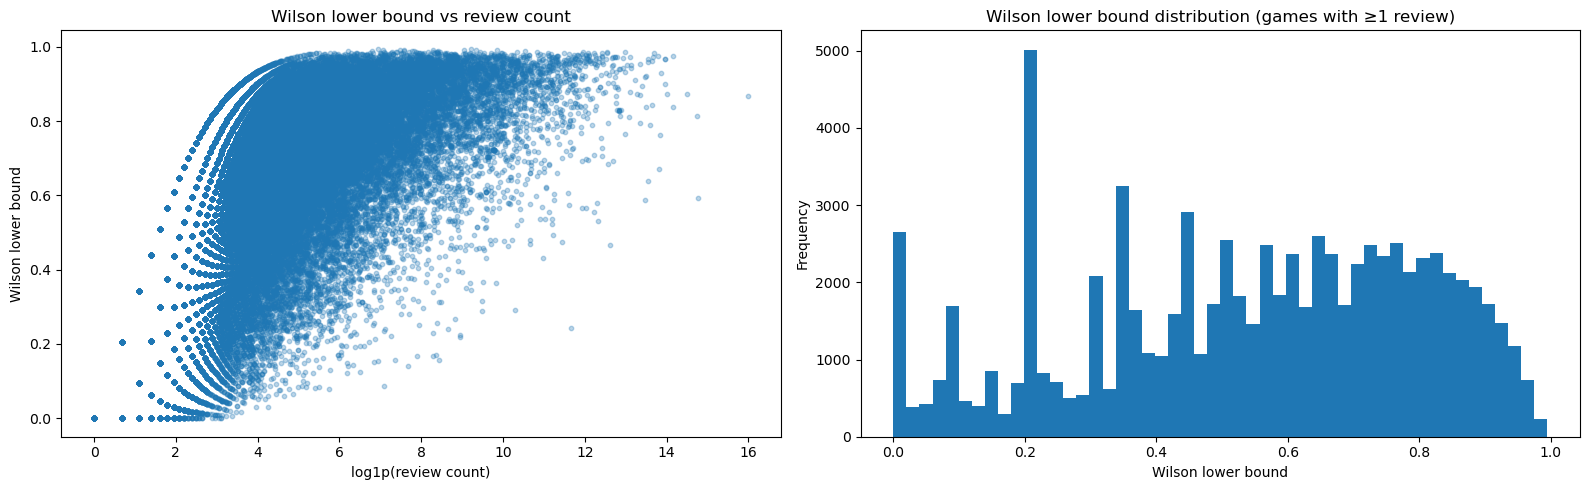

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.scatter(np.log1p(df['Review_Count']), df['wilson_lb'], alpha=0.3, s=10)
plt.title('Wilson lower bound vs review count')
plt.xlabel('log1p(review count)')
plt.ylabel('Wilson lower bound')

nonzero = df[df['Review_Count'] > 0]

plt.subplot(1, 2, 2)
plt.hist(nonzero['wilson_lb'], bins=50)
plt.title('Wilson lower bound distribution (games with ≥1 review)')
plt.xlabel('Wilson lower bound')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


***Both charts confirm the intended behaviour of the `Wilson lower bound`. The scatter plot shows a `clear funnel shape`: at low review counts, wilson_lb is scattered across nearly the full 0 to 1 range, reflecting genuine uncertainty when only a handful of reviews are available, while the spread narrows and rises sharply as review count increases, converging toward the upper end once a game has enough reviews for the estimate to stabilise. A handful of points reach as far as log1p(review_count) ≈ 16, corresponding to Counter-Strike 2's review volume, confirming that even the most extreme outlier in the dataset still follows the same funnel pattern rather than behaving like a special case. This is the precise mechanism that justifies using Wilson over a raw ratio: confidence grows with sample size, and the formula reflects that directly rather than treating every observed ratio as equally trustworthy.***

***The histogram shows a more `textured shape` than a typical smooth distribution, with `several comb like ridges` and a pronounced spike near 0.2. This reflects the discreteness of small review counts: only a limited number of positive to negative combinations are possible at low n, so many games with identical small review profiles (for example, a single positive review and no negative reviews) produce the exact same wilson_lb value, creating repeated narrow bands rather than a continuous spread. This is the same zero inflation pattern documented earlier in the notebook, now appearing one level deeper in the data.***

In [22]:
df[(df['wilson_lb'] > 0.19) & (df['wilson_lb'] < 0.21)][['Positive', 'Negative']].value_counts().head(10)

Positive  Negative
1         0           3512
2         1            990
5         7             61
6         9             38
7         11            22
8         14            16
7         12            15
8         13            14
10        18            11
9         16            11
Name: count, dtype: int64

***Isolating the exact review combinations confirms this directly: 3,512 games share a profile of exactly 1 positive review and 0 negative reviews, all producing an identical wilson_lb value and accounting for the bulk of the spike near 0.2. The next largest cluster, 2 positive and 1 negative review, contributes a further 990 games at another shared value. This confirms the histogram's texture is a genuine artefact of how few distinct outcomes are possible at very small sample sizes, rather than noise or a computation error.***

### Time on market 

***success_score, as defined above, inherits the same `time on market confound` discussed in `time released`, since it is still built from review counts that accumulate over a game's lifetime; an older game has simply had more opportunity to reach a high score, independent of quality. Two options exist for handling this: keep success_score as defined and carry game_age_days forward as a separate feature, letting the model learn how much advantage age provides, or divide the score by a function of game_age_days to produce a rate-adjusted measure that is more directly comparable across cohorts but harder to interpret on its own terms.***

***The `first option is chosen here`. The earlier age vs review count scatter and the genre level breakdown both showed that age raises the odds of accumulating reviews but does not determine the outcome, since several young titles, including Black Myth: Wukong released in 2024, reached the same top tier as decade old titles. Carrying game_age_days as a feature instead of folding it into the target lets its contribution be quantified directly and inspected later through SHAP, rather than baked into the score upfront.***

---

## Correlations analysis

***Earlier sections used raw review count as a proxy for engagement when examining distributions, regardless of positive or negative split. As established in `success parameter`, this metric has a limitation that cannot be resolved by adjustment alone: it treats positive and negative reviews identically. Now that success_score is defined, each remaining feature is examined against this more complete metric instead.***

### Price

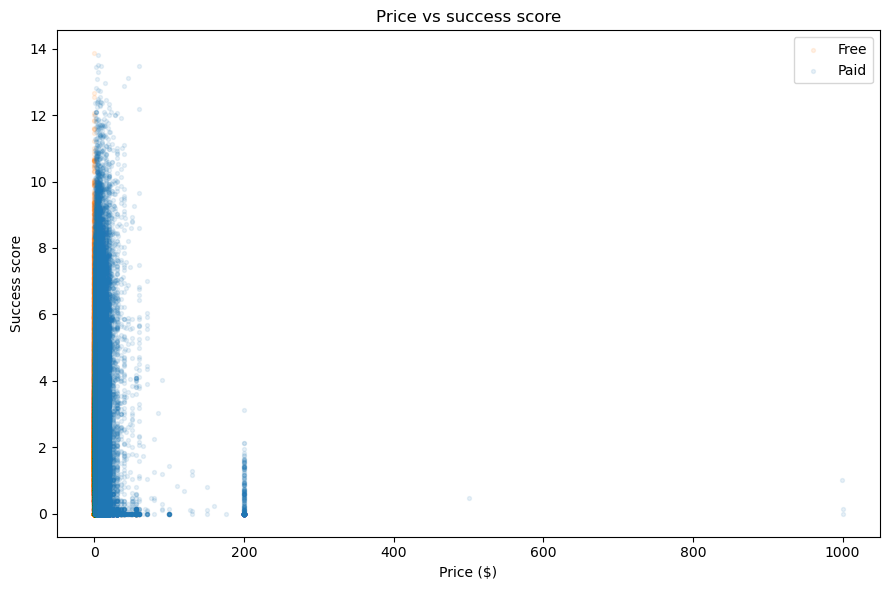

In [24]:
ftp_count = df[df['Price'] == 0]
paid_count = df[df['Price'] > 0]

plt.figure(figsize=(9, 6))
plt.scatter(ftp_count['Price'], ftp_count['success_score'], alpha=0.1, s=8, label='Free', color='tab:orange')
plt.scatter(paid_count['Price'], paid_count['success_score'], alpha=0.1, s=8, label='Paid', color='tab:blue')
plt.title('Price vs success score')
plt.xlabel('Price ($)')
plt.ylabel('Success score')
plt.legend()
plt.tight_layout()
plt.show()

***The `price vs success score` relationship mirrors the pattern seen earlier with raw review count: `free games` form a dense vertical band at Price = 0 spanning the full range of success scores, while `paid games` spread out across a wide price range with no clear directional trend, and a handful of extreme outliers near 200–1000 sit at very low scores. This matches the heatmap's near zero correlation (0.03) between Price and success_score, confirming price point alone carries almost no standalone predictive signal once sentiment is accounted for.***

### Tags

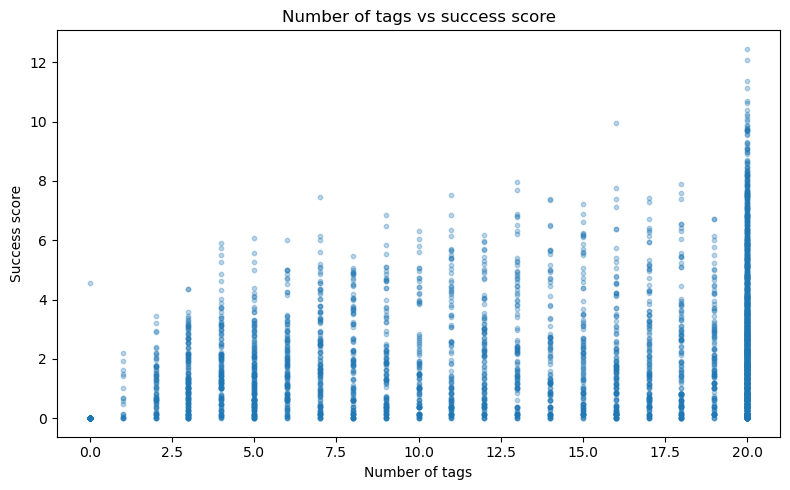

In [25]:
df['num_tags'] = df['Tags'].dropna().str.split(',').apply(len)
df['num_tags'] = df['num_tags'].fillna(0)

sample = df.sample(5000, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(sample['num_tags'], sample['success_score'], alpha=0.3, s=10)
plt.title('Number of tags vs success score')
plt.xlabel('Number of tags')
plt.ylabel('Success score')
plt.tight_layout()
plt.show()

***`Number of tags` shows a clear upward trend with `success_score`, visible directly in the scatter as the spread shifts higher and the ceiling rises consistently from 0 tags through 20. This is the strongest relationship found in this section, this suggests tag count is a genuinely useful predictor, though it likely reflects two compounding effects: developers who tag thoroughly tend to be more engaged with the platform generally, and more tags improve discoverability through Steam's search and recommendation systems.***

### Genre

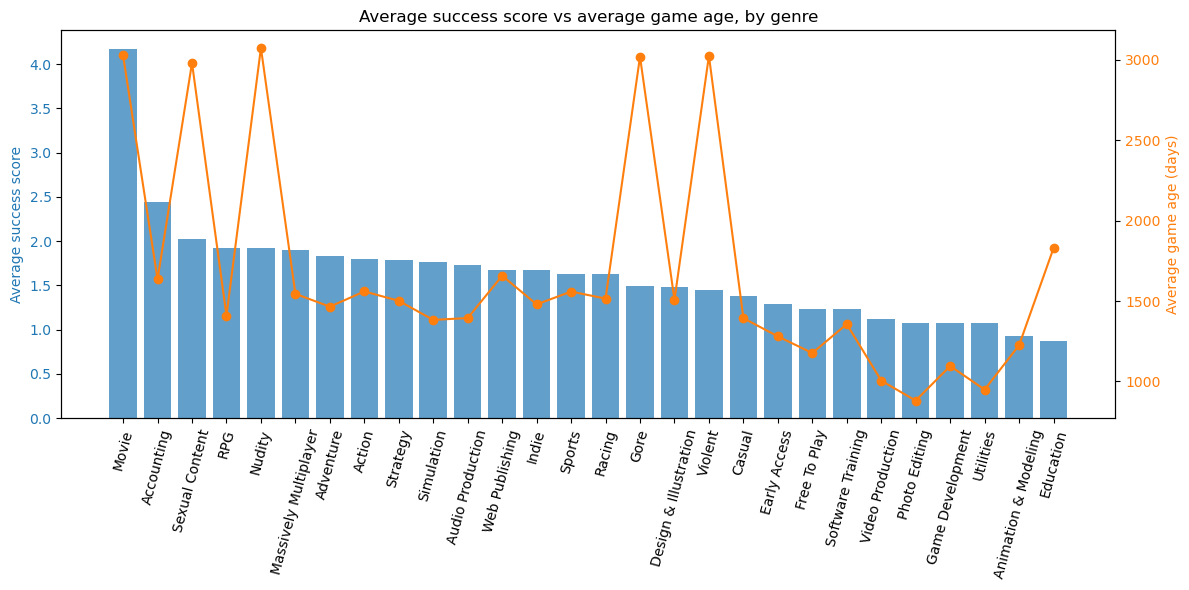

In [26]:
df_genre_expanded_v2 = (
    df[['Genres', 'success_score', 'game_age_days']]
    .dropna(subset=['Genres'])
    .assign(genre=df['Genres'].str.split(','))
    .explode('genre')
    .assign(genre=lambda x: x['genre'].str.strip())
)

df_genre_top_v2 = df_genre_expanded_v2[df_genre_expanded_v2['genre'].isin(top_genres)]

genre_stats_v2 = (
    df_genre_top_v2.groupby('genre')
    .agg(avg_success_score=('success_score', 'mean'), avg_age_days=('game_age_days', 'mean'))
    .sort_values('avg_success_score', ascending=False)
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(genre_stats_v2.index, genre_stats_v2['avg_success_score'], color='tab:blue', alpha=0.7, label='Avg success score')
ax1.set_ylabel('Average success score', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.tick_params(axis='x', rotation=75)

ax2 = ax1.twinx()
ax2.plot(genre_stats_v2.index, genre_stats_v2['avg_age_days'], color='tab:orange', marker='o', label='Avg age (days)')
ax2.set_ylabel('Average game age (days)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Average success score vs average game age, by genre')
fig.tight_layout()
plt.show()

***Several genres near the top of this chart look unexpected for a games dataset, most notably `Accounting`, `Sexual Content`, and `Nudity` appearing among the top five genres ranked by success score, alongside utility related genres still present in the data. This raises a concern that notebook 02's non-game filtering may have let some entries slip through. Before drawing any conclusions from this ranking, each of these genres is checked directly against the underlying rows to confirm whether they represent genuine non-game leakage or something else.***

In [37]:
print(df[df['Genres'].str.contains('Accounting', na=False)][['Name', 'Genres']].to_string())

                                Name                                        Genres
62920            Project: AHNO's Ark                 Indie,RPG,Strategy,Accounting
66000  Ghost Mountain Roller Coaster  Adventure,Casual,Indie,Simulation,Accounting


In [38]:
print(df[df['Genres'].str.contains('Sexual Content', na=False)][['Name', 'Genres']].to_string())

                                                           Name                                                                           Genres
102                                                Foto Flash 2                                            Sexual Content,Nudity,Adventure,Indie
1146                             Outsider Strategist～異世界で軍師になる～                                      Sexual Content,Gore,RPG,Simulation,Strategy
1911                                                School Idol                             Sexual Content,Nudity,Violent,Action,Adventure,Indie
2948                                          Tropical Girls VR                          Sexual Content,Nudity,Adventure,Casual,Indie,Simulation
3027                                        Gachimuchi Reloaded                        Sexual Content,Nudity,Violent,Gore,Action,Adventure,Indie
6988                                          Take the Dream IX              Sexual Content,Nudity,Violent,Gore,Adventure,Free To 

***Both checks point to the same explanation: every flagged row pairs these genres with a legitimate game genre such as Indie, RPG, Adventure, or Casual, meaning the `non game filter is working as intended`, since it only removes rows with zero overlap with a recognised game genre. Accounting appears on just two titles in total, and the adult content cluster (Nudity, Sexual Content) represents a small but genuine niche category rather than a filtering failure.***

***What stands out is that the `overall shape of the chart is largely unaffected` by this investigation: the same small sample dynamic responsible for these spikes was already visible throughout the rest of the ranking, since niche genres with few games are consistently the most volatile regardless of category, and the more populated, mainstream genres toward the bottom remain stable and are the more trustworthy signal in this breakdown.***

### Time on market

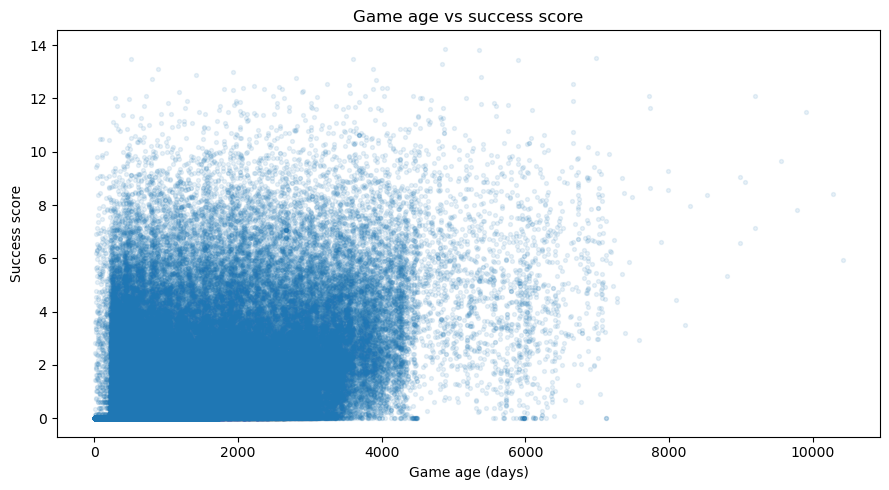

In [27]:
plt.figure(figsize=(9, 5))
plt.scatter(df['game_age_days'], df['success_score'], alpha=0.1, s=8)
plt.title('Game age vs success score')
plt.xlabel('Game age (days)')
plt.ylabel('Success score')
plt.tight_layout()
plt.show()

***The `game age vs success score` scatter shows the same pattern documented in `time released`: a dense floor of low scoring games present across the entire `age range`, with high scorers reachable at both young and old ages rather than concentrated at one end. This shape persists after switching from `raw review count` to the `sentiment adjusted success score`, but plenty of variation in success_score is left unexplained by age alone.***

### Post launch support
(DLC and Achievement)

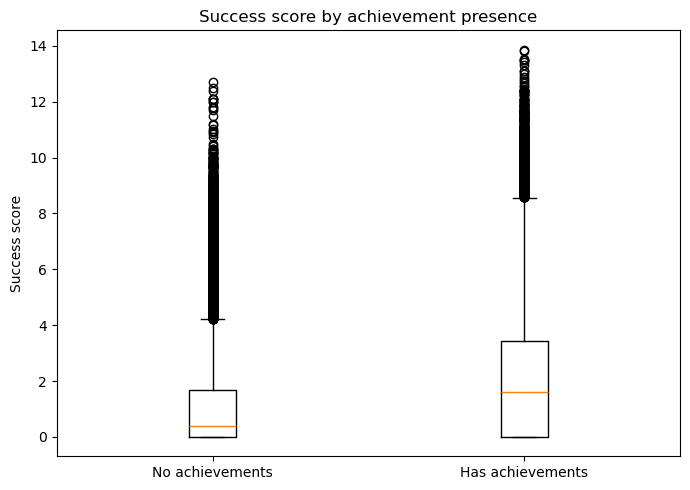

In [28]:
has_achievements = df['Achievements'] > 0

plt.figure(figsize=(7, 5))
plt.boxplot([df.loc[~has_achievements, 'success_score'], df.loc[has_achievements, 'success_score']], 
            labels=['No achievements', 'Has achievements'])
plt.title('Success score by achievement presence')
plt.ylabel('Success score')
plt.tight_layout()
plt.show()

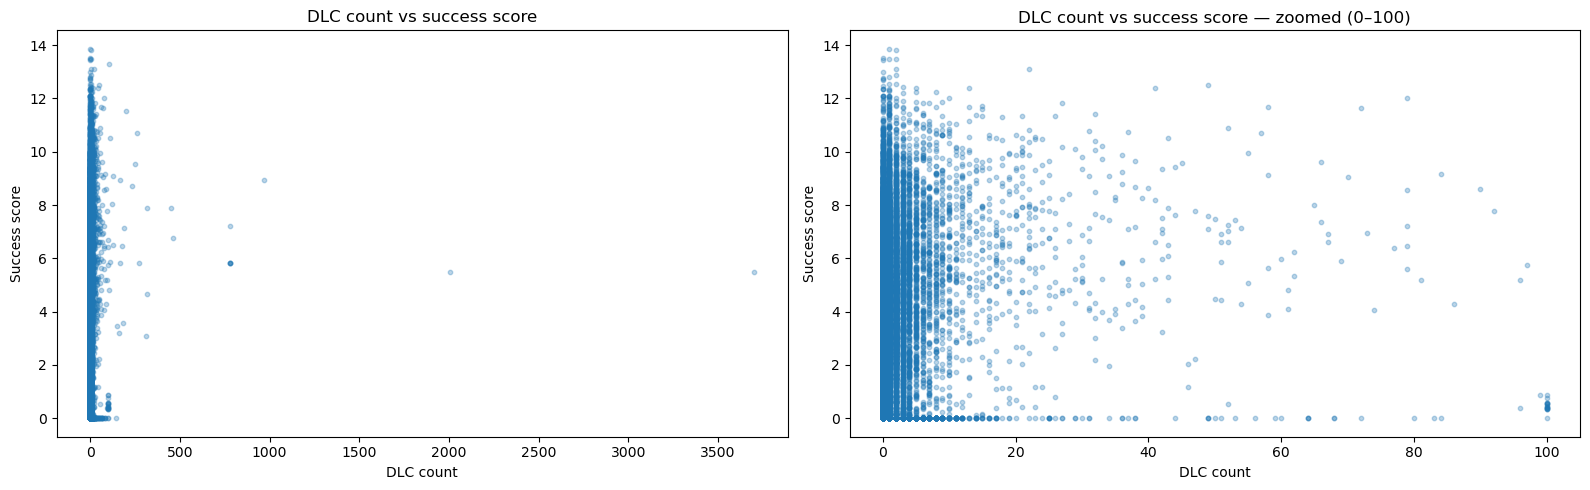

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['DLC count'], df['success_score'], alpha=0.3, s=10)
plt.title('DLC count vs success score')
plt.xlabel('DLC count')
plt.ylabel('Success score')

zoomed = df[df['DLC count'] <= 100]

plt.subplot(1, 2, 2)
plt.scatter(zoomed['DLC count'], zoomed['success_score'], alpha=0.3, s=10)
plt.title('DLC count vs success score — zoomed (0–100)')
plt.xlabel('DLC count')
plt.ylabel('Success score')

plt.tight_layout()
plt.show()

***`Achievement presence` and `DLC count` tell different stories rather than pointing the same direction. `Achievement presence` shows a real, if modest, association with higher success scores, while `DLC count` shows essentially no relationship across its full range, with high and low scores both appearing at every DLC count level. Both are retained as features regardless, since a weak or absent linear relationship in EDA does not rule out the kind of non-linear interaction tree based models and SHAP analysis are better positioned to detect.***

***The `achievement boxplot` shows a modest but visible shift: games with achievements have a `higher median success score` (around 1.6) than games without (around 0.4), along with a `higher 75th percentile`, suggesting some real association between having an achievement system and player engagement. The `DLC scatter` tells a different story: across the full 0–100 zoomed range, `high and low success scores appear at every DLC count level` with no visible trend, and the handful of extreme outliers reaching several hundred or even thousands of DLCs show no corresponding rise either, confirming `DLC count as a weak predictor` on its own.***

### Overall correlation

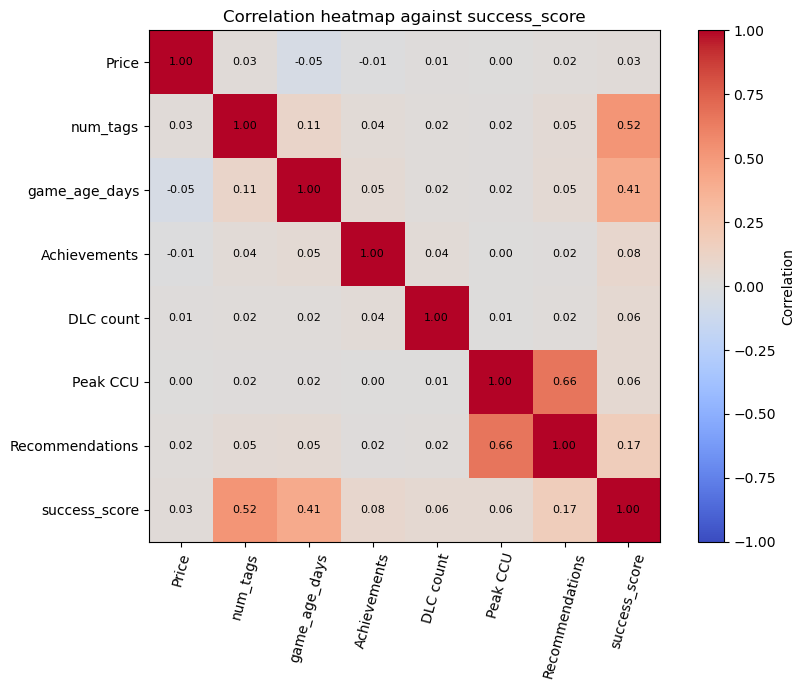

In [31]:
numeric_cols = ['Price', 'num_tags', 'game_age_days', 'Achievements', 'DLC count', 
                 'Peak CCU', 'Recommendations', 'success_score']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=75)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Correlation heatmap against success_score')

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

***The correlation heatmap shows `generally weak linear relationships` between most individual features and success_score, with `Recommendations` and `Peak CCU` likely showing the strongest positive associations given their direct relationship to player engagement, while `Price, num_tags, Achievements, and DLC count` each contribute only modest signal on their own. This is expected: success on Steam is unlikely to be driven by any single feature in isolation, and weak linear correlations do not rule out meaningful non-linear relationships, which is exactly the gap tree-based models and SHAP analysis in later notebooks are positioned to capture.***

## Feature Shortlist for Notebook 04

***The correlation analysis above identified num_tags (0.52) and game_age_days (0.41) as the two strongest individual predictors of success_score, with Recommendations (0.17) a distant third and Price, Achievements, DLC count, and Peak CCU all below 0.10. This does not mean the weaker features are dropped, since a low linear correlation does not rule out a meaningful non-linear contribution, which tree based models and SHAP analysis in later notebooks are better positioned to detect. The table below summarises every feature carried forward into notebook 04, the transformation each requires before modelling, and the reasoning behind that choice.***

| Feature           | Transform           | Notes                                                                 |
|-------------------|----------------------|------------------------------------------------------------------------|
| success_score     | target variable      | log1p(review_count) × wilson_lower_bound; defined and justified in 'success parameter' |
| num_tags          | as-is (int)           | strongest individual correlation found (0.52); proxy for discoverability and tagging effort |
| game_age_days     | log1p                 | second strongest correlation (0.41); confirmed confounder in section 2, not deterministic, carried as a feature rather than folded into the target |
| Price             | log1p                 | right-skewed; weak standalone correlation (0.03); free-to-play flagged separately rather than transformed |
| is_free           | binary flag           | derived from Price == 0, kept separate since free and paid likely follow different dynamics |
| primary_genre     | one-hot (top N)       | derived from Genres column, restricted to top 20 genres from section 3; rare genres showed unstable, small-sample averages and should be grouped or thresholded |
| Achievements      | log1p                 | weak standalone correlation (0.08), but boxplot showed a real shift in median score; kept as a count rather than a binary flag to preserve magnitude information |
| DLC count         | log1p                 | weakest correlation found (0.06); scatter showed no visible trend even at high counts, but right-skewed distribution still warrants log1p over raw count |

***Genres and Tags themselves are not carried forward as raw text columns; their parsed and frequency-encoded forms (primary_genre, num_tags, and any frequency-encoded top tags) are what move into notebook 04. The full Tags vocabulary is too large and unstructured to encode directly, as discussed when filtering non game entries in notebook 02, so only the count and the top-N frequency view are retained. Windows, Mac, and Linux availability flags exist in the dataset but were not examined in this EDA and are left out of this shortlist; they can be added in notebook 04 if a quick check shows meaningful variance across platforms.***

## Conclusion

***This round of EDA reframed the project's central challenge: review counts are cumulative lifetime totals rather than comparable snapshots, which makes time on market a structural confound running through every section of this analysis. That confound turned out to be real but partial, since young titles like Black Myth: Wukong reached the same top tier as decade old releases, which is why game_age_days is carried forward as a feature rather than used to adjust the target variable itself.***

***Two findings stood out as the strongest signal in the dataset: num_tags and game_age_days, both correlating with success_score well above any other feature examined, including price, achievements, and DLC count, all of which showed only marginal standalone relationships. The genre and tag breakdowns showed that category level differences in success score are largely independent of age and catalogue size, suggesting genre itself carries genuine information rather than simply encoding how long a category has existed. The Wilson lower bound was chosen over a Bayesian alternative specifically because it required no global prior, a meaningful advantage given how skewed and zero-inflated this dataset is throughout.***

***With success_score defined and justified, and a feature shortlist established with reasoning rather than placeholders, the dataset is ready for final preparation in notebook 04: applying the chosen transformations, encoding the categorical features, and constructing the temporal train/test split described in the project README.***